In [2]:
from utilities import init_bigquery_client
from google.cloud import bigquery
import os
import pandas as pd
import numpy as np
import plotly.express as px

from plotnine import *

#init BigQuery client
bq = init_bigquery_client()

Using BigQuery credentials: etl-testing-478716-c0b6c2c512e0.json


## Bulk Queries

In [3]:
# Read from the 'events' table in BigQuery
query = """
    SELECT *
    FROM `etl-testing-478716.firebase_etl_prod.events`
"""
events_df = bq.query(query).to_dataframe()

# Read from the 'userinvites' table in BigQuery
query = """
    SELECT *
    FROM `etl-testing-478716.firebase_etl_prod.userinvites`
"""
userinvites_df = bq.query(query).to_dataframe()

# Read from the 'users' table in BigQuery
query = """
    SELECT *
    FROM `etl-testing-478716.firebase_etl_prod.users`
"""
users_df = bq.query(query).to_dataframe()

/opt/miniconda3/envs/heyyall/lib/python3.13/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.


In [4]:
#Creating previous joiners df for network analysis
userinvites_df.rename(columns={'user_id': 'invite_user_id',
                               'createdAt': 'invite_created_at'}, inplace=True)

events_df.rename(columns={'user_id': 'event_user_id',
                          'createdAt': 'event_created_at'}, inplace=True)

# Merge the 'events' and 'userinvites' DataFrames on the 'event_id' column
merged_df = pd.merge(events_df, userinvites_df, left_on = 'document_id', 
                     right_on='event_id', how='inner', suffixes=('_events', '_userinvites'))
keep_columns = ['event_id', 'title', 'invite_user_id','event_user_id','type','status', 'invite_created_at', 'event_created_at']

filtered_df = merged_df[keep_columns]
filtered_df = filtered_df[filtered_df['status'] == 'accepted']
filtered_df = filtered_df.drop_duplicates(subset=['event_id', 'invite_user_id', 'event_user_id','type','status'])

#getting count of how many times each user attended events planned by each event planner
previous_joiners_df = filtered_df.groupby(['invite_user_id', 'event_user_id']).size().reset_index(name='pair_count')

#merging on if event planner is a businses user
biz_user_df = users_df[['user_id', 'businessUser']]

previous_joiners_df = previous_joiners_df.merge(biz_user_df, left_on='event_user_id', right_on='user_id', how='left')
previous_joiners_df['businessUser'] = previous_joiners_df['businessUser'].fillna(False)
previous_joiners_df = previous_joiners_df.rename(columns={'businessUser':'event_businessUser'})

In [5]:
#getting span of time user has been attending events planned by each event planner
first_attend_df = filtered_df.groupby(['invite_user_id', 'event_user_id'])['invite_created_at'].min().reset_index(name='first_attend_date')
last_attend_df = filtered_df.groupby(['invite_user_id', 'event_user_id'])['invite_created_at'].max().reset_index(name='last_attend_date')

previous_joiners_df = previous_joiners_df.merge(first_attend_df, on=['invite_user_id', 'event_user_id'], how='left')
previous_joiners_df = previous_joiners_df.merge(last_attend_df, on=['invite_user_id', 'event_user_id'], how='left')

previous_joiners_df['attend_span'] = (previous_joiners_df['last_attend_date'] - previous_joiners_df['first_attend_date']).dt.total_seconds() / 3600

### Generating Network Graph

In [6]:
import networkx as nx
import matplotlib.pyplot as plt
import scipy as sp

In [7]:
#segmenting previous joiner networks by general event planners and business event planners
G_general_user = nx.from_pandas_edgelist(previous_joiners_df[previous_joiners_df['event_businessUser'] == False], 'invite_user_id', 'event_user_id')
G_business_user = nx.from_pandas_edgelist(previous_joiners_df[previous_joiners_df['event_businessUser'] == True], 'invite_user_id', 'event_user_id')

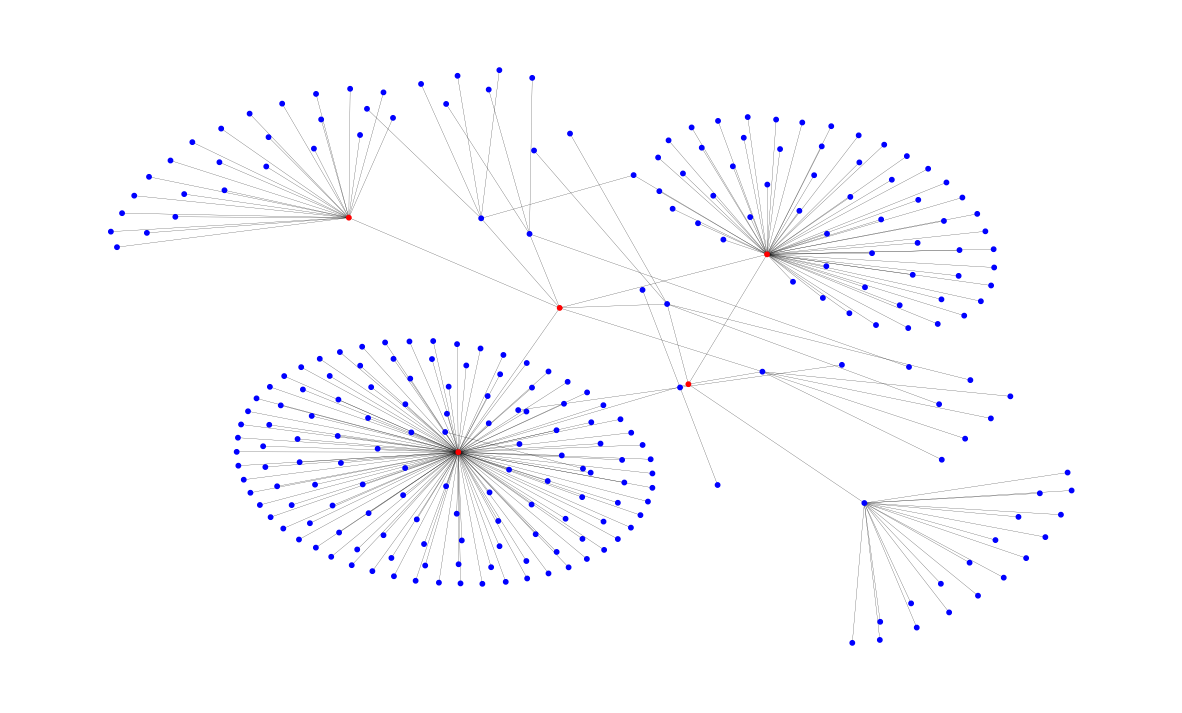

In [8]:
#Creating graphic of business user previous joiner network
betweeness_centrality = nx.centrality.betweenness_centrality(G_business_user)

# Find top 5 nodes by betweenness centrality
top5_nodes = sorted(betweeness_centrality, key=betweeness_centrality.get, reverse=True)[:5]

# Assign colors: red for top 5, blue for others
node_colors = ["red" if node in top5_nodes else "blue" for node in G_business_user.nodes()]

pos = nx.kamada_kawai_layout(G_business_user)
fig, ax = plt.subplots(figsize=(15, 9))
ax.axis("off")
plot_options = {"node_size": 10, "with_labels": False, "width": 0.15}
nx.draw_networkx(G_business_user, pos=pos, ax=ax, node_color=node_colors, **plot_options)

In [17]:
pos = nx.circular_layout(G)
fig, ax = plt.subplots(figsize=(15, 9))
ax.axis("off")
plot_options = {"node_size": 10, "with_labels": False, "width": 0.15}
nx.draw_networkx(G, pos=pos, ax=ax, **plot_options)

NameError: name 'G' is not defined

### Degree centrality

Identifying which event planners have the highest degree and which attendees go to the most distinct events by planner

In [9]:
#Degree centrality of event planners 
event_planner_centrality = nx.degree_centrality(G_business_user)

## Bipartite Network Analysis

A bipartite network is one where you can separate nodes into distinct sets. There can be edges between the sets but not within sets. 
For our work using a bipartite network with business users and event attendees as our distinct sets allows for easier interpretation.

In [10]:
# Add nodes with bipartite attribute
# 0 = attendees, 1 = planners
#filtering to business user event planners
df = previous_joiners_df[previous_joiners_df['event_businessUser']==True]
G = nx.Graph()

#creating attendee and planner lists
attendees = df['invite_user_id'].unique()
planners = df['event_user_id'].unique()

G.add_nodes_from(attendees, bipartite=0, node_type='attendee')
G.add_nodes_from(planners, bipartite=1, node_type='planner')

# Add weighted edges
edges = [(row['invite_user_id'], row['event_user_id'], row['pair_count']) 
         for _, row in df.iterrows()]
G.add_weighted_edges_from(edges)

print(f"Graph created with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
print(f"Attendees: {len(attendees)}, Planners: {len(planners)}")

Graph created with 261 nodes and 262 edges
Attendees: 251, Planners: 10


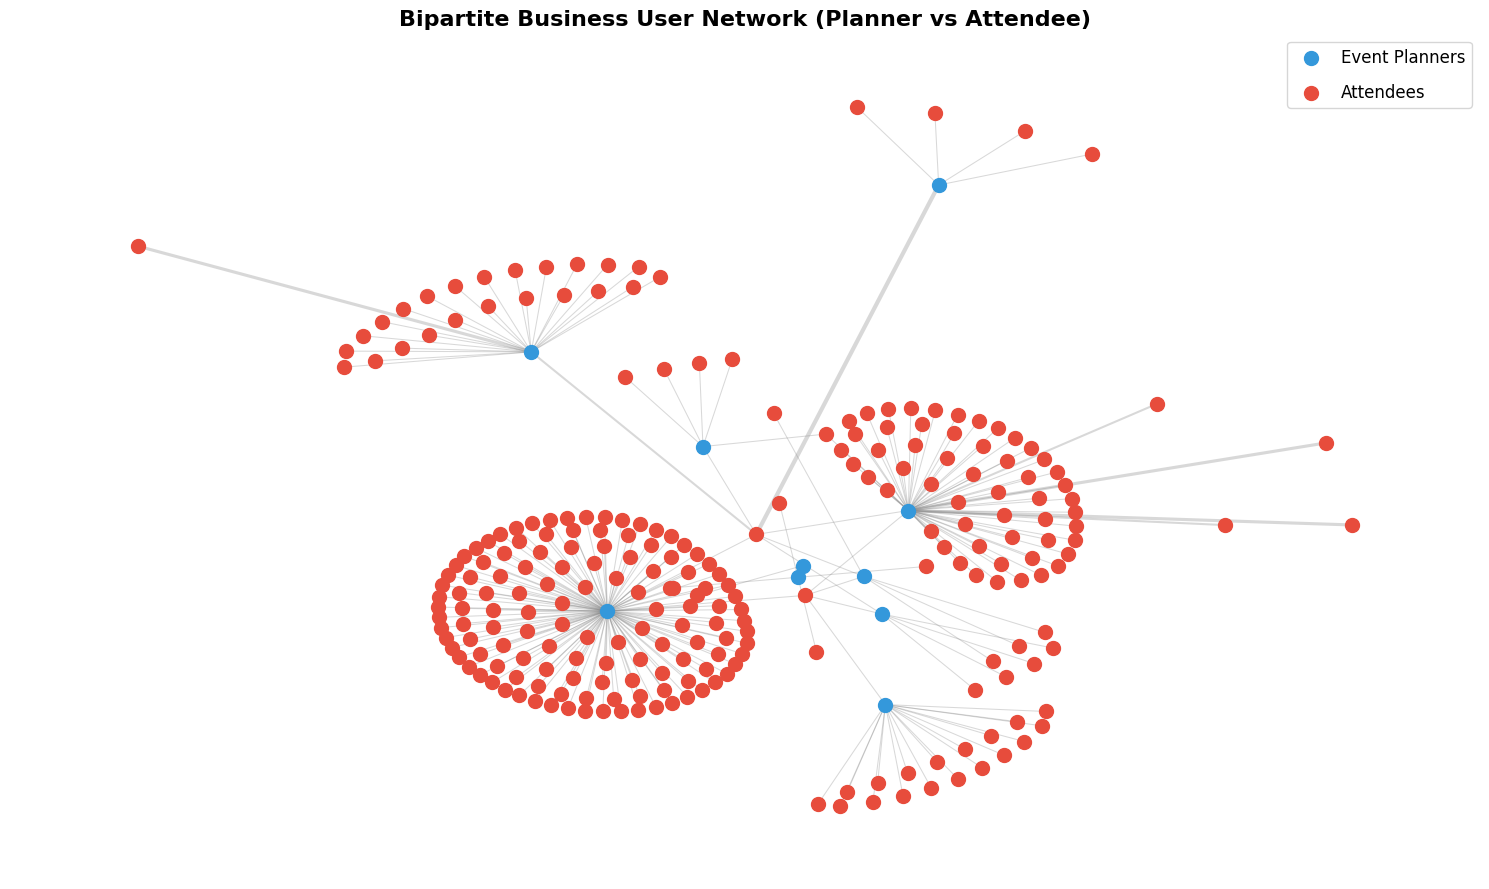

In [11]:
def visualize_bipartite_kamada_kawai(G, title="Event Planning Network"):
    """
    Visualize bipartite network with Kamada-Kawai layout
    """
    attendees = {n for n, d in G.nodes(data=True) if d['bipartite'] == 0}
    planners = {n for n, d in G.nodes(data=True) if d['bipartite'] == 1}
    
    # Kamada-Kawai layout
    pos = nx.kamada_kawai_layout(G, weight='weight')
    
    plt.figure(figsize=(15, 9))
    
    # Draw planners (blue, larger)
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=planners,
        node_color='#3498db',
        node_size=100,
        label='Event Planners'
    )
    
    # Draw attendees (orange, smaller)
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=attendees,
        node_color='#e74c3c',
        node_size=100,
        label='Attendees'
    )
    
    # Draw edges with varying width based on pair_count
    edges = G.edges(data=True)
    weights = [d['weight'] for u, v, d in edges]
    max_weight = max(weights)
    
    nx.draw_networkx_edges(
        G, pos,
        width=[w/max_weight * 3 for w in weights],
        alpha=0.3,
        edge_color='gray'
    )
    
    plt.title(title, fontsize=16, fontweight='bold')
    plt.legend(scatterpoints=1, frameon=True, labelspacing=1, fontsize=12)
    plt.axis('off')
    plt.tight_layout()
    # plt.savefig('bipartite_network_kamada_kawai.png', dpi=300, bbox_inches='tight')
    plt.show()


visualize_bipartite_kamada_kawai(G, title="Bipartite Business User Network (Planner vs Attendee)")


Projection turns the bipartite graph into a unipartite graph where event planners are connected and overlapping attendees are returned as the edge weight.

Business Insights:

* Competitor Analysis: Planners with many shared attendees have overlapping audiences
* Collaboration Opportunities: Planners with moderate overlap might benefit from co-hosting
* Market Segmentation: Planners with no connections serve completely different niches
* Cross-promotion: Planners with high overlap could recommend each other's events


In [12]:
#projected networks 
def create_projected_networks(G):
    """
    Create planner-to-planner and attendee-to-attendee projections
    """
    attendees = {n for n, d in G.nodes(data=True) if d['bipartite'] == 0}
    planners = {n for n, d in G.nodes(data=True) if d['bipartite'] == 1}
    
    # Planner projection (planners connected by shared attendees)
    planner_projection = nx.bipartite.weighted_projected_graph(G, planners)
    
    # Attendee projection (attendees connected by shared planners)
    attendee_projection = nx.bipartite.weighted_projected_graph(G, attendees)
    
    return planner_projection, attendee_projection

planner_proj, attendee_proj = create_projected_networks(G)
#extracting planner to planner pairings with count of attendee overlap
def get_projection_edges_df(projection_graph, node1_col='planner_1', node2_col='planner_2'):
    """
    Convert projection graph to a DataFrame of all edges with weights
    """
    edges_data = []
    
    for u, v, data in projection_graph.edges(data=True):
        edges_data.append({
            node1_col: u,
            node2_col: v,
            'weight': data.get('weight', 1),  # Number of shared attendees
            'planner_1_degree': projection_graph.degree(u, weight='weight'),
            'planner_2_degree': projection_graph.degree(v, weight='weight')
        })
    
    df_edges = pd.DataFrame(edges_data)
    
    # Add normalized metrics
    if len(df_edges) > 0:
        # Jaccard-style normalization (shared / total unique attendees)
        # This requires going back to original bipartite graph
        df_edges['avg_degree'] = (df_edges['planner_1_degree'] + df_edges['planner_2_degree']) / 2
        df_edges['overlap_ratio'] = df_edges['weight'] / df_edges['avg_degree']
    
    return df_edges.sort_values('weight', ascending=False)

# Get all planner-to-planner connections
planner_edges_df = get_projection_edges_df(planner_proj, 'planner_1', 'planner_2')

Planner recommendation engine: given an input planner id output best planners they could throw events with

In [16]:
def get_planner_recommendations(planner_id, G, planner_edges_df, top_n=3):
    """
    Get top collaboration recommendations for a specific planner
    
    Parameters:
    -----------
    planner_id : ID of the planner to get recommendations for
    G : NetworkX bipartite graph
    planner_edges_df : DataFrame with planner projection edges (from get_projection_edges_df)
    top_n : number of recommendations to return
    
    Returns:
    --------
    DataFrame with collaboration insights
    """
    # Get this planner's attendees
    planner_attendees = set(G.neighbors(planner_id))
    planner_total_attendance = sum(G[planner_id][att]['weight'] for att in planner_attendees)
    
    # Get all connections for this planner
    connections = planner_edges_df[
        (planner_edges_df['planner_1'] == planner_id) | 
        (planner_edges_df['planner_2'] == planner_id)
    ].copy()
    
    # Normalize so focal planner is always in planner_1
    connections['focal_planner'] = planner_id
    connections['recommended_planner'] = connections.apply(
        lambda row: row['planner_2'] if row['planner_1'] == planner_id else row['planner_1'],
        axis=1
    )
    
    # Calculate detailed metrics for each potential collaborator
    recommendations = []
    
    for _, row in connections.iterrows():
        rec_planner = row['recommended_planner']
        shared_count = row['weight']
        
        # Get recommended planner's attendees
        rec_planner_attendees = set(G.neighbors(rec_planner))
        rec_total_attendance = sum(G[rec_planner][att]['weight'] for att in rec_planner_attendees)
        
        # Calculate overlap and new audience metrics
        shared_attendees = planner_attendees & rec_planner_attendees
        new_attendees = rec_planner_attendees - planner_attendees
        
        # Calculate weighted metrics (accounting for pair_count)
        shared_weight_focal = sum(G[planner_id][att]['weight'] for att in shared_attendees)
        shared_weight_rec = sum(G[rec_planner][att]['weight'] for att in shared_attendees)
        new_audience_weight = sum(G[rec_planner][att]['weight'] for att in new_attendees)
        
        # Collaboration potential score
        # Higher score = more new audience + some overlap (shows compatibility)
        overlap_ratio = len(shared_attendees) / len(planner_attendees) if planner_attendees else 0
        new_audience_ratio = len(new_attendees) / len(rec_planner_attendees) if rec_planner_attendees else 0
        
        # Score: balance between new audience and proven overlap
        # Sweet spot is 20-40% overlap (proves compatibility without being too redundant)
        overlap_score = 1 - abs(overlap_ratio - 0.3)  # Peaks at 30% overlap
        collaboration_score = (len(new_attendees) * overlap_score * 100)
        
        # Potential combined audience size
        combined_unique_attendees = len(planner_attendees | rec_planner_attendees)
        
        recommendations.append({
            'recommended_planner': rec_planner,
            'shared_attendees': len(shared_attendees),
            'focal_planner_size': len(planner_attendees),
            'recommended_planner_size': len(rec_planner_attendees),
            'new_attendees_count': len(new_attendees),
            'new_attendees_percentage': (len(new_attendees) / len(planner_attendees) * 100) if planner_attendees else 0,
            'overlap_percentage': overlap_ratio * 100,
            'combined_reach': combined_unique_attendees,
            'reach_increase': combined_unique_attendees - len(planner_attendees),
            'reach_increase_percentage': ((combined_unique_attendees - len(planner_attendees)) / len(planner_attendees) * 100) if planner_attendees else 0,
            'shared_weight_focal': shared_weight_focal,
            'shared_weight_recommended': shared_weight_rec,
            'new_audience_weight': new_audience_weight,
            'collaboration_score': collaboration_score,
            'recommendation_type': classify_collaboration_type(overlap_ratio, len(new_attendees), len(planner_attendees))
        })
    
    # Convert to DataFrame and sort by collaboration score
    rec_df = pd.DataFrame(recommendations).sort_values('collaboration_score', ascending=False)
    
    # Return top N
    return rec_df.head(top_n)


def classify_collaboration_type(overlap_ratio, new_attendees, focal_size):
    """
    Classify the type of collaboration opportunity
    """
    if overlap_ratio > 0.6:
        return "High Overlap - Consider Different Partner"
    elif overlap_ratio > 0.4:
        return "Competitor - Co-market to Shared Base"
    elif overlap_ratio > 0.2 and new_attendees > focal_size * 0.5:
        return "IDEAL - Good Fit with Growth Potential"
    elif overlap_ratio > 0.1 and new_attendees > focal_size * 0.3:
        return "Growth Partner - Expand Audience"
    elif new_attendees > focal_size:
        return "Large Untapped Audience"
    else:
        return "Limited Synergy"
    
def get_planner_name(planner_id, users_df):
    """
    Get the name of a planner given their ID
    """
    planner_info = users_df[users_df['user_id'] == planner_id]
    if not planner_info.empty:
        return planner_info.iloc[0]['fullName']
    else:
        return "Unknown Planner"


def print_recommendations(planner_id, G, planner_edges_df, top_n=3):
    """
    Print formatted recommendations for a planner
    """
    recommendations = get_planner_recommendations(planner_id, G, planner_edges_df, top_n)

    planner_name = get_planner_name(planner_id, users_df)
    
    if recommendations.empty:
        print(f"No recommendations found for planner {planner_name} ({planner_id})")
        return
    
    print("=" * 80)
    print(f"COLLABORATION RECOMMENDATIONS FOR PLANNER {planner_name} ({planner_id})")
    print("=" * 80)
    
    planner_attendees = set(G.neighbors(planner_id))
    print(f"Your Current Reach: {len(planner_attendees)} unique attendees")
    print(f"Top {top_n} Collaboration Opportunities:")
    
    for idx, row in recommendations.iterrows():
        print(f"\n{'─' * 80}")
        recommended_planner_name = get_planner_name(row['recommended_planner'], users_df)
        print(f"RANK #{recommendations.index.get_loc(idx) + 1}: Partner with Planner {recommended_planner_name} ({row['recommended_planner']})")
        print(f"{'─' * 80}")
        print(f"Type: {row['recommendation_type']}")
        print(f"\n AUDIENCE METRICS:")
        print(f"   • Their Audience Size: {row['recommended_planner_size']} attendees")
        print(f"   • Shared Attendees: {row['shared_attendees']} ({row['overlap_percentage']:.1f}% overlap)")
        print(f"   • NEW Attendees You'd Reach: {row['new_attendees_count']} ({row['new_attendees_percentage']:.1f}% increase)")
        print(f"\n COLLABORATION IMPACT:")
        print(f"   • Combined Reach: {row['combined_reach']} unique attendees")
        print(f"   • Your Reach Increase: +{row['reach_increase']} attendees (+{row['reach_increase_percentage']:.1f}%)")
    
    print(f"\n{'=' * 80}\n")
    
    return recommendations

In [17]:
print_recommendations(planner_id='xqtYGaFNqxTJURg1vK1sZwU37zi2', G=G, planner_edges_df=planner_edges_df, top_n=2)

COLLABORATION RECOMMENDATIONS FOR PLANNER Tritone Jazz Sessions (xqtYGaFNqxTJURg1vK1sZwU37zi2)
Your Current Reach: 61 unique attendees
Top 2 Collaboration Opportunities:

────────────────────────────────────────────────────────────────────────────────
RANK #1: Partner with Planner ONO Agency (Z347q5fi8fUr1eeY2mt2W8rrmN92)
────────────────────────────────────────────────────────────────────────────────
Type: Large Untapped Audience

 AUDIENCE METRICS:
   • Their Audience Size: 129 attendees
   • Shared Attendees: 2 (3.3% overlap)
   • NEW Attendees You'd Reach: 127 (208.2% increase)

 COLLABORATION IMPACT:
   • Combined Reach: 188 unique attendees
   • Your Reach Increase: +127 attendees (+208.2%)

────────────────────────────────────────────────────────────────────────────────
RANK #2: Partner with Planner Melody Durand Comedy (0MFEFCTVAmScoWdnIrrP6duF6pU2)
────────────────────────────────────────────────────────────────────────────────
Type: Limited Synergy

 AUDIENCE METRICS:
   • Th

,recommended_planner,shared_attendees,focal_planner_size,recommended_planner_size,new_attendees_count,new_attendees_percentage,overlap_percentage,combined_reach,reach_increase,reach_increase_percentage,shared_weight_focal,shared_weight_recommended,new_audience_weight,collaboration_score,recommendation_type
2,Z347q5fi8fUr1eeY2mt2W8rrmN92,2,61,129,127,208.196721,3.278689,188,127,208.196721,2,2,127,9306.393443,Large Untapped Audience
4,0MFEFCTVAmScoWdnIrrP6duF6pU2,1,61,25,24,39.344262,1.639344,85,24,39.344262,1,2,26,1719.344262,Limited Synergy


### Attendee Diversity

Using the following we can get a visualization of the total previous joiner graph to understand which attendees are the most active with regard to diveristy of planners.

Computing Kamada-Kawai layout...


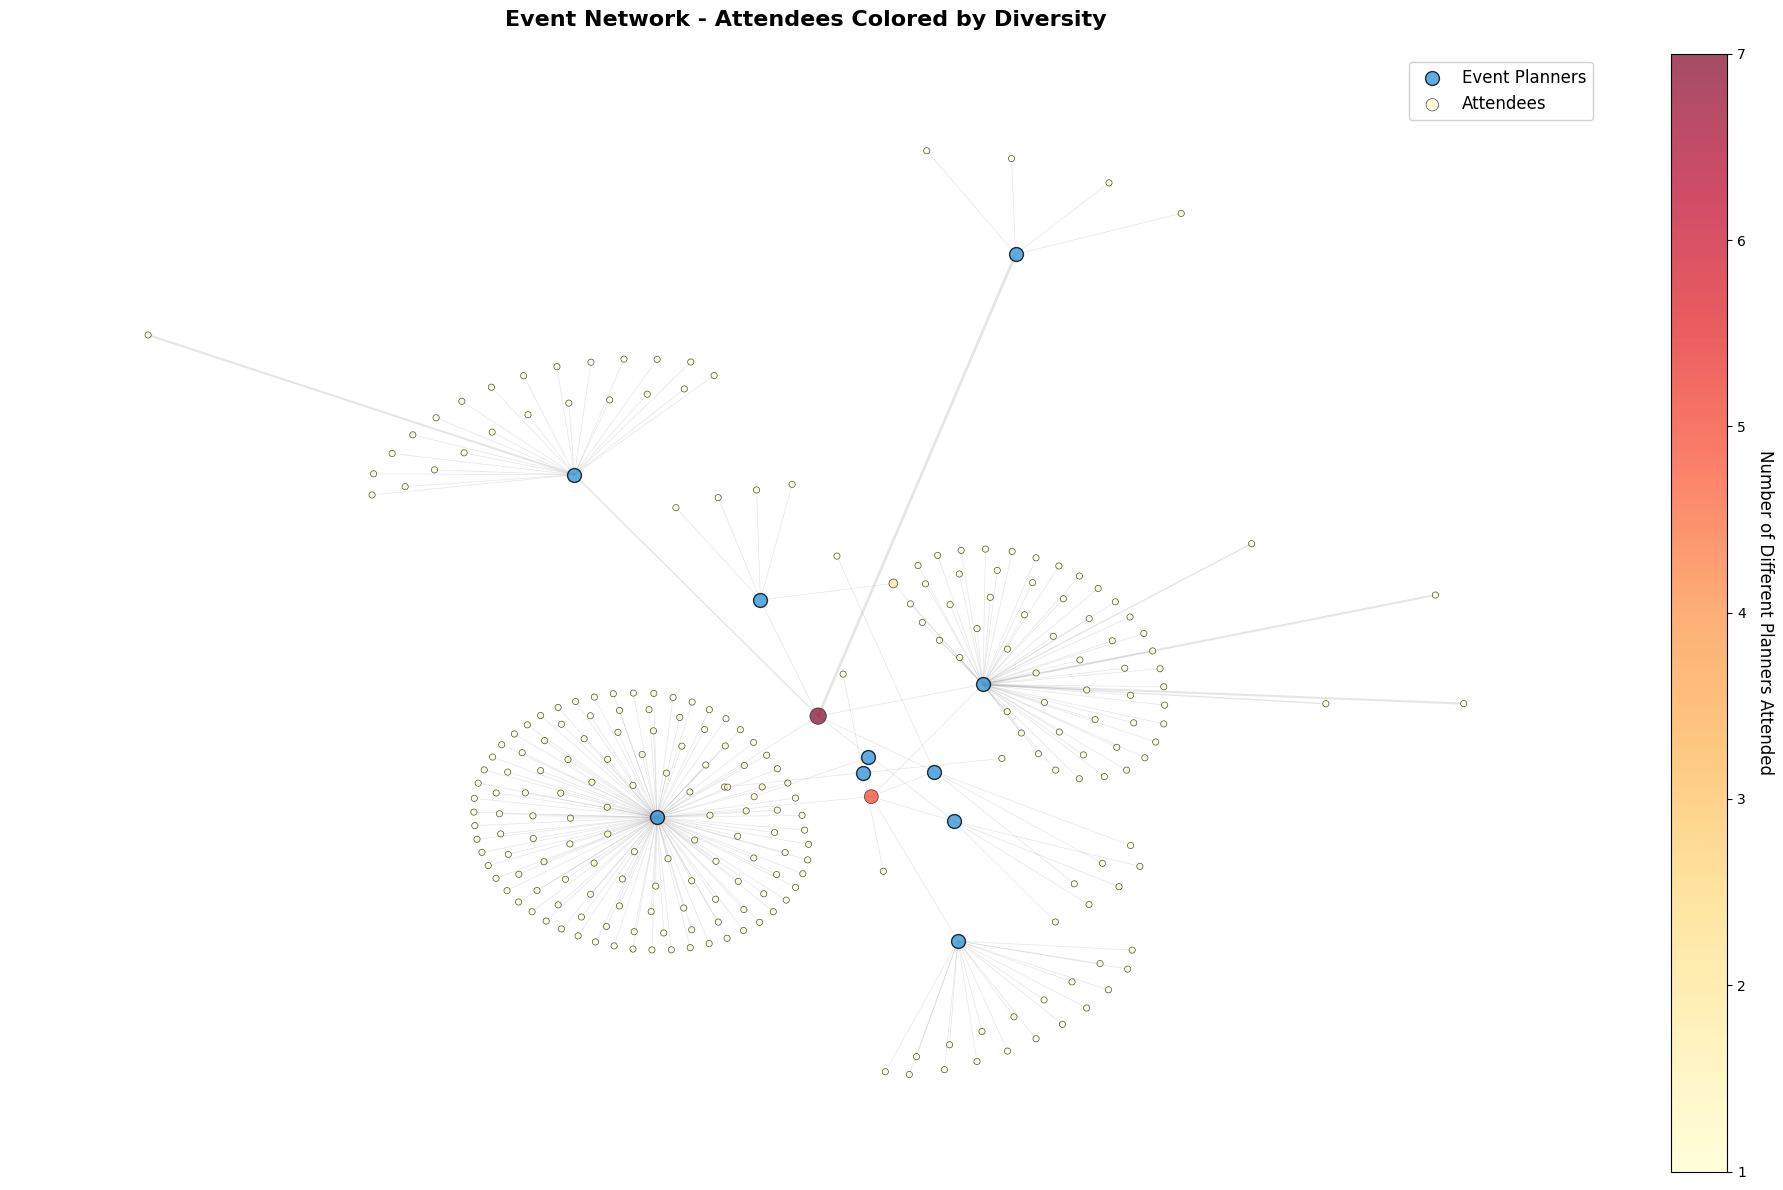

In [15]:
def calculate_attendee_diversity(G):
    """
    Calculate how many different planners each attendee has attended
    
    Parameters:
    -----------
    G : NetworkX bipartite graph
    
    Returns:
    --------
    dict : {attendee_id: number_of_planners_attended}
    """
    attendees = {n for n, d in G.nodes(data=True) if d.get('bipartite') == 0}
    
    attendee_diversity = {}
    for attendee in attendees:
        # Count number of different planners this attendee is connected to
        num_planners = G.degree(attendee)
        attendee_diversity[attendee] = num_planners
    
    return attendee_diversity

def visualize_attendee_diversity(G, layout_pos=None, 
                                 colormap='YlOrRd',
                                 planner_size=200,
                                 attendee_size_multiplier=20,
                                 show_labels=False,
                                 title="Event Network - Attendees Colored by Diversity"):
    """
    Visualize the bipartite network with attendees colored by number of planners attended
    
    Parameters:
    -----------
    G : NetworkX bipartite graph
    layout_pos : pre-computed layout positions (optional)
    colormap : matplotlib colormap for attendee coloring
    planner_size : size of planner nodes
    attendee_size_multiplier : multiplier for attendee node sizes
    show_labels : whether to show node labels
    title : plot title
    
    Returns:
    --------
    fig, ax, layout_pos
    """
    # Separate nodes by type
    attendees = {n for n, d in G.nodes(data=True) if d.get('bipartite') == 0}
    planners = {n for n, d in G.nodes(data=True) if d.get('bipartite') == 1}
    
    # Calculate attendee diversity
    attendee_diversity = calculate_attendee_diversity(G)
    
    # Get diversity values for color mapping
    attendee_list = list(attendees)
    diversity_values = [attendee_diversity[a] for a in attendee_list]
    
    # Calculate node sizes based on diversity
    attendee_sizes = [attendee_diversity[a] * attendee_size_multiplier for a in attendee_list]
    
    # Calculate layout
    if layout_pos is None:
        print("Computing Kamada-Kawai layout...")
        layout_pos = nx.kamada_kawai_layout(G, weight='weight')
    
    # Create figure
    fig, ax = plt.subplots(figsize=(18, 12))
    
    # Draw planners (blue, uniform size)
    planner_nodes = nx.draw_networkx_nodes(
        G, layout_pos, ax=ax,
        nodelist=list(planners),
        node_color='#3498db',
        node_size=planner_size,
        alpha=0.8,
        label='Event Planners',
        edgecolors='black',
        linewidths=1
    )
    
    # Draw attendees (colored by diversity)
    if diversity_values:
        attendee_nodes = nx.draw_networkx_nodes(
            G, layout_pos, ax=ax,
            nodelist=attendee_list,
            node_color=diversity_values,
            node_size=attendee_sizes,
            cmap=colormap,
            vmin=min(diversity_values),
            vmax=max(diversity_values),
            alpha=0.7,
            label='Attendees',
            edgecolors='black',
            linewidths=0.5
        )
        
        # Add colorbar
        cbar = plt.colorbar(attendee_nodes, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('Number of Different Planners Attended', 
                      rotation=270, labelpad=20, fontsize=12)
    
    # Draw edges with varying width based on pair_count
    edges = G.edges(data=True)
    weights = [d['weight'] for u, v, d in edges]
    max_weight = max(weights) if weights else 1
    
    nx.draw_networkx_edges(
        G, layout_pos, ax=ax,
        width=[w/max_weight * 2 for w in weights],
        alpha=0.2,
        edge_color='gray'
    )
    
    # Add labels if requested
    if show_labels:
        # Label planners
        planner_labels = {p: f"P{p}" for p in planners}
        nx.draw_networkx_labels(
            G, layout_pos, ax=ax,
            labels=planner_labels,
            font_size=8,
            font_weight='bold'
        )
        
        # Label top diverse attendees
        top_attendees = sorted(attendee_diversity.items(), 
                              key=lambda x: x[1], reverse=True)[:10]
        attendee_labels = {a: f"A{a}\n({div})" for a, div in top_attendees}
        nx.draw_networkx_labels(
            G, layout_pos, ax=ax,
            labels=attendee_labels,
            font_size=7,
            font_color='darkred',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7)
        )
    
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.legend(loc='upper right', fontsize=12, framealpha=0.9)
    plt.axis('off')
    plt.tight_layout()
    
    return fig, ax, layout_pos

# Usage
fig, ax, pos = visualize_attendee_diversity(
    G,
    colormap='YlOrRd',  # Yellow to Red
    planner_size=100,
    show_labels=False
)
# plt.savefig('attendee_diversity_network.png', dpi=300, bbox_inches='tight')
plt.show()